In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


sns.set_theme(style="whitegrid")


plt.rcParams["figure.figsize"] = (6,5)

In [2]:
case_1 = pd.read_excel("case_study1.xlsx")
case_2 = pd.read_excel("case_study2.xlsx")

case_2.replace(-99999, np.nan, inplace=True)

case_2["pct_currentBal_all_TL"] = (
    case_2["pct_currentBal_all_TL"]
    .fillna(case_2["pct_currentBal_all_TL"].median())
)

In [3]:
df = case_1.merge(case_2, on="PROSPECTID") #merging the two datasets on PROSPECTID to create a combined dataset for analysis

In [4]:
df.shape

(51336, 87)

In [16]:
df.groupby("Approved_Flag")["Credit_Score"].median()

Approved_Flag
P1    712.0
P2    682.0
P3    665.0
P4    650.0
Name: Credit_Score, dtype: float64

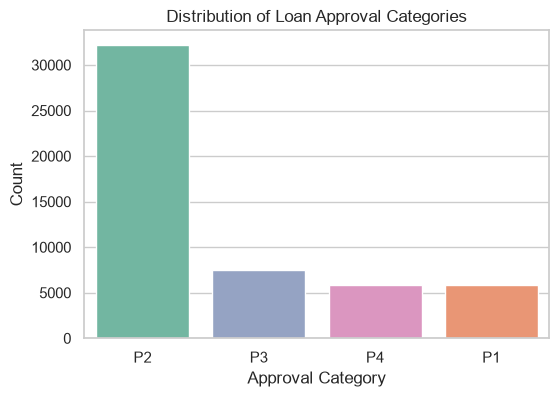

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Approved_Flag",
    hue="Approved_Flag",
    palette="Set2",
    order=df["Approved_Flag"].value_counts().index
)

plt.title("Distribution of Loan Approval Categories")
plt.xlabel("Approval Category")
plt.ylabel("Count")

plt.show()

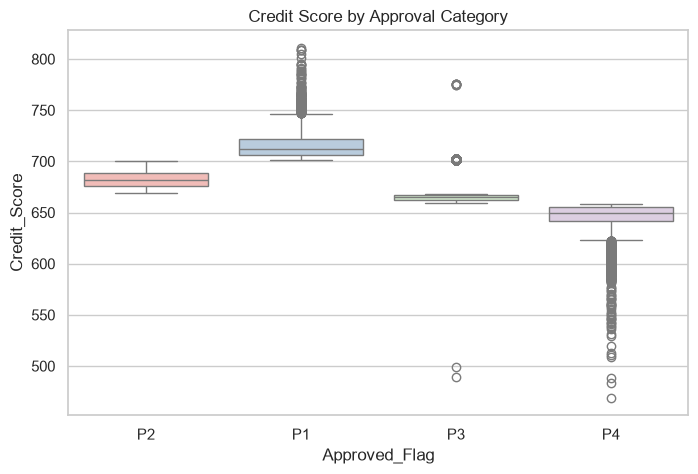

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Approved_Flag",
    hue="Approved_Flag",
    y="Credit_Score",
    palette="Pastel1"
)

plt.title("Credit Score by Approval Category")
plt.show()

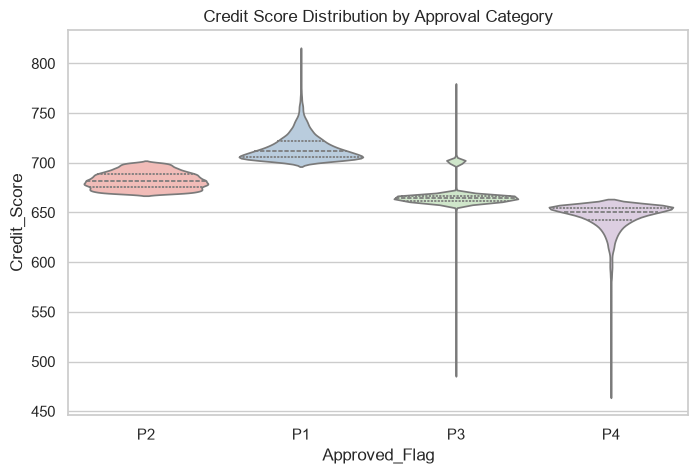

In [15]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Approved_Flag",
    hue="Approved_Flag",
    y="Credit_Score",
    palette="Pastel1",
    inner="quartile"
)

plt.title("Credit Score Distribution by Approval Category")
plt.show()

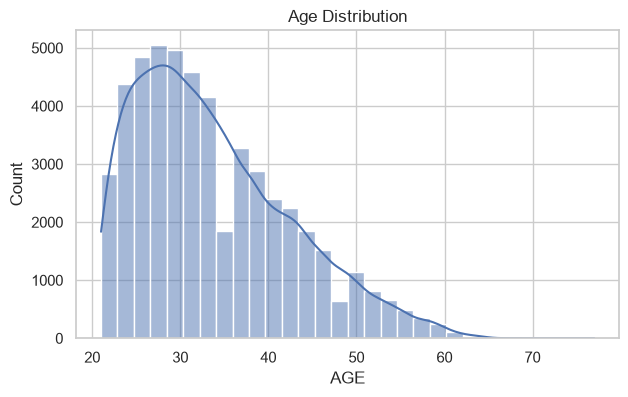

In [17]:
plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x="AGE",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

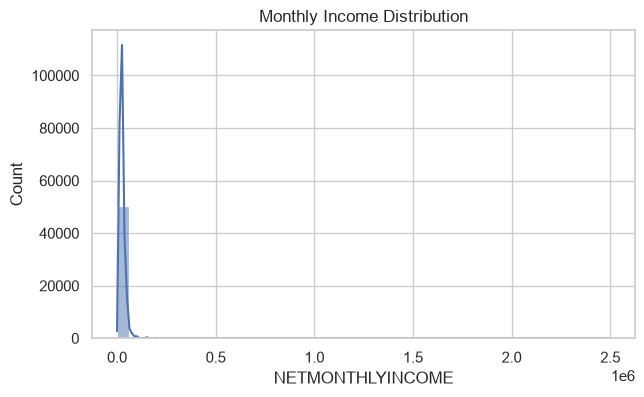

In [18]:
plt.figure(figsize=(7,4))

sns.histplot(
    data=df,
    x="NETMONTHLYINCOME",
    bins=40,
    kde=True
)

plt.title("Monthly Income Distribution")
plt.show()

C:\Users\Aditi\AppData\Local\Temp\ipykernel_22776\3780986228.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


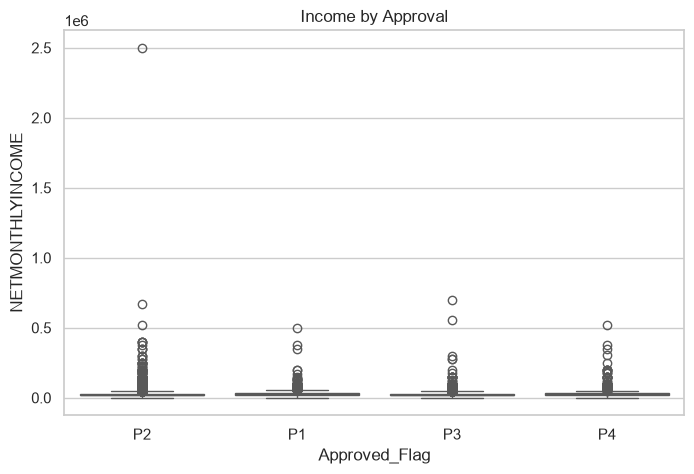

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Approved_Flag",
    y="NETMONTHLYINCOME",
    palette="Set2"
)

plt.title("Income by Approval")
plt.show()

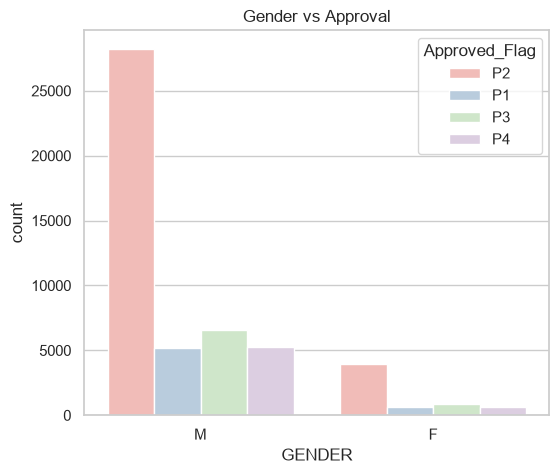

In [22]:
sns.countplot(
    data=df,
    x="GENDER",
    hue="Approved_Flag",
    palette="Pastel1"
)

plt.title("Gender vs Approval")
plt.show()

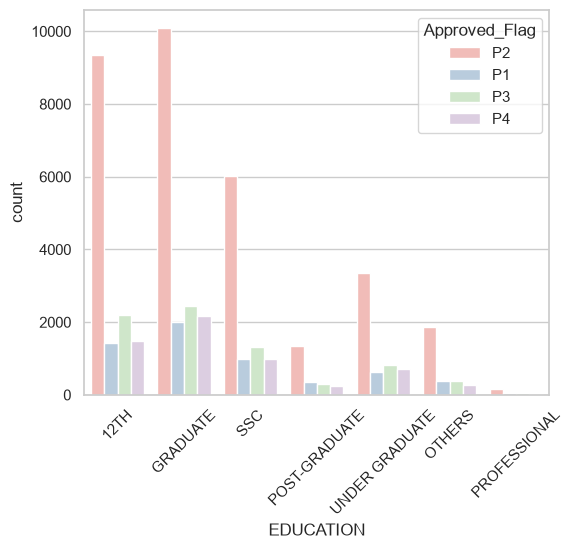

In [24]:
sns.countplot(
    data=df,
    x="EDUCATION",
    hue="Approved_Flag",
    palette="Pastel1"
)

plt.xticks(rotation=45)
plt.show()

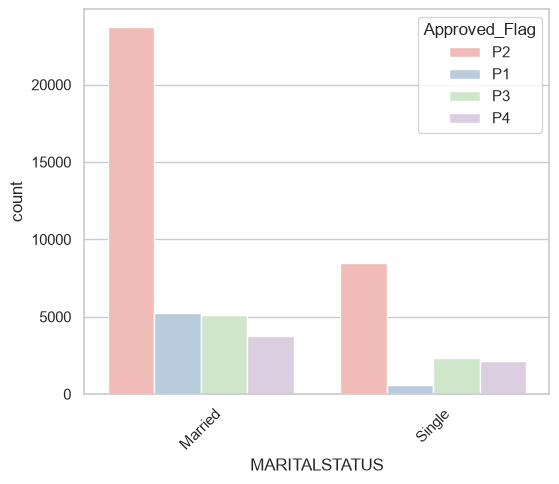

In [ ]:
sns.countplot(
    data=df,
    x="MARITALSTATUS",
    hue="Approved_Flag",
    palette="Pastel1"
)

plt.xticks(rotation=45)
plt.show()

In [28]:
df["Log_Income"] = np.log1p(df["NETMONTHLYINCOME"])

<Axes: xlabel='Log_Income', ylabel='Count'>

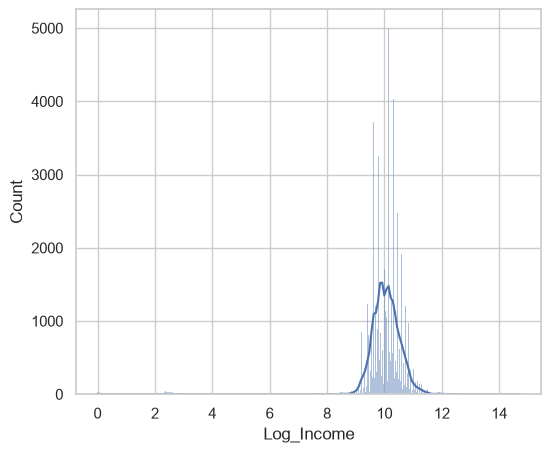

In [29]:
sns.histplot(df["Log_Income"], kde=True)

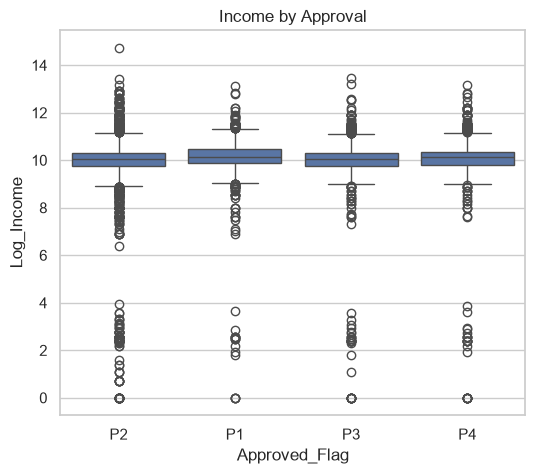

In [30]:
sns.boxplot(
    data=df,
    x="Approved_Flag",
    y="Log_Income"
)
plt.title("Income by Approval")
plt.show()

In [33]:
df.groupby("Approved_Flag")[["Credit_Score", "NETMONTHLYINCOME", "AGE"]].agg(
    ["mean", "median", "std"]
).round(2)

Credit_Score               NETMONTHLYINCOME                     \
                      mean median    std             mean   median       std   
Approved_Flag                                                                  
P1                  715.95  712.0  13.49         29071.37  25000.0  17475.34   
P2                  682.58  682.0   8.33         25886.79  23000.0  21240.48   
P3                  667.00  665.0  11.30         25938.47  23000.0  17529.13   
P4                  645.63  650.0  15.51         27369.68  24715.0  18185.88   

                 AGE               
                mean median   std  
Approved_Flag                      
P1             39.80   39.0  8.88  
P2             33.53   32.0  8.64  
P3             32.14   30.0  8.19  
P4             31.11   29.0  7.75

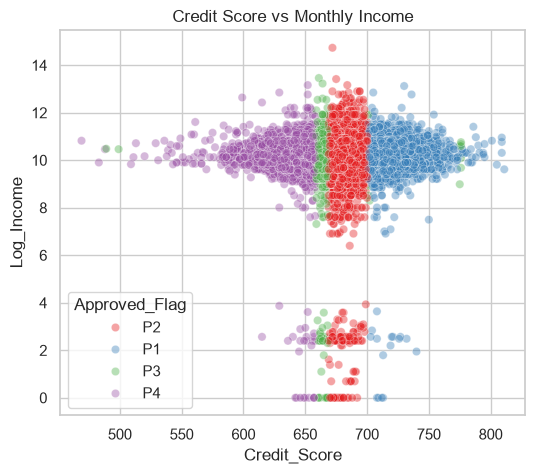

In [39]:
sns.scatterplot(
    data=df,
    x="Credit_Score",
    y="Log_Income",
    hue="Approved_Flag",
    palette="Set1",
    alpha=0.4
)

plt.title("Credit Score vs Monthly Income")
plt.show()

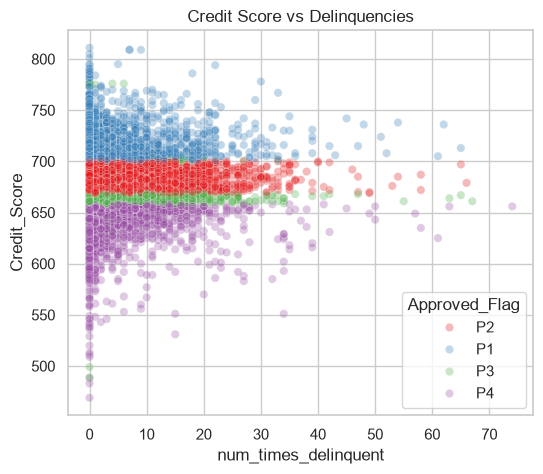

In [41]:
sns.scatterplot(
    data=df,
    x="num_times_delinquent",
    y="Credit_Score",
    hue="Approved_Flag",
    palette="Set1",
    alpha=0.3
)

plt.title("Credit Score vs Delinquencies")
plt.show()

In [43]:
feature_summary = df.groupby("Approved_Flag").agg({
    "Credit_Score":"median",
    "NETMONTHLYINCOME":"median",
    "AGE":"median",
    "num_times_delinquent":["median", "mean"],
    "tot_enq":["median", "mean"]
}).round(2)

feature_summary

Credit_Score NETMONTHLYINCOME    AGE num_times_delinquent        \
                    median           median median               median  mean   
Approved_Flag                                                                   
P1                   712.0          25000.0   39.0                  0.0  1.82   
P2                   682.0          23000.0   32.0                  0.0  1.26   
P3                   665.0          23000.0   30.0                  0.0  1.99   
P4                   650.0          24715.0   29.0                  1.0  2.52   

              tot_enq         
               median   mean  
Approved_Flag                 
P1                3.0   5.14  
P2                3.0   4.19  
P3                4.0   5.63  
P4                7.0  10.24

In [ ]:
# Key Findings 📺

# Median credit score steadily decreases from 712 (P1) to 650 (P4), 
# -- indicating a strong relationship between credit score and approval priority.
# Median age also declines across approval categories, 
# --suggesting older applicants tend to receive better approval ratings.
# Median monthly income shows little variation across approval groups, 
# --indicating income alone is not a strong differentiator.
# P4 applicants have the highest median and mean number of credit enquiries, 
# --suggesting frequent recent borrowing attempts are associated with lower approval categories.
# Median delinquency count is 0 for P1–P3 but 1 for P4, 
# --while the large gap between median and mean indicates a right-skewed distribution with a subset of applicants having many delinquent events.
